🏠 Scenario: Real Estate Price Prediction

You are developing a regression model to predict house prices.

Dataset contains:

House Size (sqft)

Number of Tiles

Total Construction Cost

Number of Bedrooms

Market Price

After calculating correlation matrix, you find:

House Size and Number of Tiles have 0.98 correlation

Construction Cost is highly correlated (0.95) with House Size

In [1]:
import pandas as pd
df = pd.DataFrame({
    "House_Size": [1000, 1200, 1500, 1800, 2000],
    "Number_of_Tiles": [2000, 2400, 3000, 3600, 4000],
    "Construction_Cost": [50000, 60000, 75000, 90000, 100000],
    "Bedrooms": [2, 3, 3, 4, 4],
    "Market_Price": [150000, 180000, 220000, 260000, 300000]
})

In [2]:
import numpy as np
X = df.drop("Market_Price", axis=1)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
threshold = 0.9
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated features to remove:")
print(to_drop)

Highly correlated features to remove:
['Number_of_Tiles', 'Construction_Cost', 'Bedrooms']


In [3]:
# Drop features
X_reduced = X.drop(columns=to_drop)

print("\nRemaining features:")
print(X_reduced.columns)


Remaining features:
Index(['House_Size'], dtype='object')


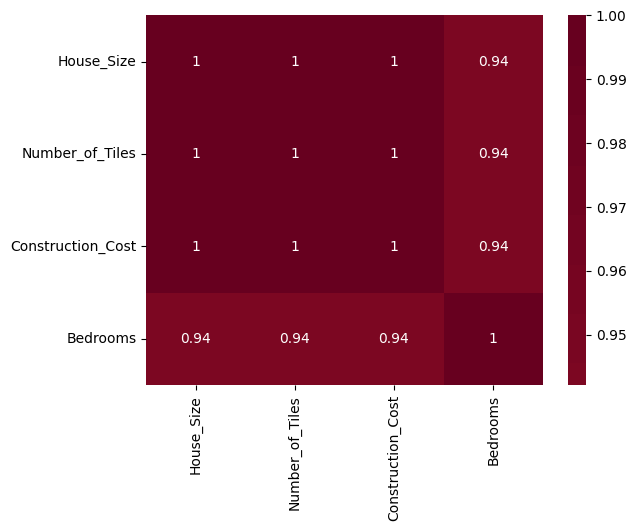

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0)
plt.show()